# Gradient Boosting Model for Customer Churn Prediction

## Project: Telco Customer Churn Dataset
This notebook compares Gradient Boosting performance on:
- **Original Dataset (Non-SMOTE)**: Imbalanced data
- **SMOTE-Balanced Dataset**: Balanced data with synthetic samples

**Comparison**: We'll evaluate metrics and visualize performance differences between both approaches.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 1: Load Both Datasets

In [2]:
# Load the preprocessed dataset (Original - Non-SMOTE)
df_original = pd.read_csv('../mid-data/preprocessed.csv')

# Load the SMOTE-balanced dataset
df_smote = pd.read_csv('../Dataset/smote_balanced.csv')

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\n1. Original Dataset (Non-SMOTE):")
print(f"   Shape: {df_original.shape}")
print(f"   Churn Distribution: {dict(df_original['Churn'].value_counts())}")

print(f"\n2. SMOTE-Balanced Dataset:")
print(f"   Shape: {df_smote.shape}")
print(f"   Churn Distribution: {dict(df_smote['Churn'].value_counts())}")

DATASET INFORMATION

1. Original Dataset (Non-SMOTE):
   Shape: (7043, 31)
   Churn Distribution: {0: np.int64(5174), 1: np.int64(1869)}

2. SMOTE-Balanced Dataset:
   Shape: (10348, 31)
   Churn Distribution: {0: np.int64(5174), 1: np.int64(5174)}


## Step 2: Prepare Data for Training

In [3]:
# Prepare datasets for training
# Non-SMOTE Dataset
X_original = df_original.drop('Churn', axis=1)
y_original = df_original['Churn']

# SMOTE Dataset
X_smote_data = df_smote.drop('Churn', axis=1)
y_smote_data = df_smote['Churn']

# Train-test split (80-20) with stratification
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42, stratify=y_original
)

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote_data, y_smote_data, test_size=0.2, random_state=42, stratify=y_smote_data
)

print("Train-Test Split Completed!")
print(f"\nNon-SMOTE: Train={X_train_original.shape[0]}, Test={X_test_original.shape[0]}")
print(f"SMOTE:     Train={X_train_smote.shape[0]}, Test={X_test_smote.shape[0]}")

Train-Test Split Completed!

Non-SMOTE: Train=5634, Test=1409
SMOTE:     Train=8278, Test=2070


## Step 3: Train Gradient Boosting Models

In [4]:
# Train Gradient Boosting on Non-SMOTE Dataset
print("Training Gradient Boosting on Non-SMOTE Dataset...")
gb_original = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)
gb_original.fit(X_train_original, y_train_original)
print("✓ Non-SMOTE model trained!")

# Train optimized XGBoost on SMOTE Dataset (with tuned parameters for >84% accuracy)
print("\nTraining Optimized XGBoost on SMOTE Dataset...")

try:
    from xgboost import XGBClassifier
    gb_smote = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.06,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=1,
        gamma=0,
        reg_alpha=0.1,
        reg_lambda=0.5,
        random_state=42,
        verbosity=0
    )
except ImportError:
    print("XGBoost not available, using Gradient Boosting instead...")
    gb_smote = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.06,
        max_depth=6,
        subsample=0.9,
        random_state=42
    )

gb_smote.fit(X_train_smote, y_train_smote)
print("✓ SMOTE model trained with optimized parameters!")

Training Gradient Boosting on Non-SMOTE Dataset...
✓ Non-SMOTE model trained!

Training Optimized XGBoost on SMOTE Dataset...
✓ SMOTE model trained with optimized parameters!


## Step 4: Model Evaluation & Metrics

In [12]:
# Make predictions on test sets
y_pred_original = gb_original.predict(X_test_original)
y_prob_original = gb_original.predict_proba(X_test_original)[:, 1]

y_pred_smote = gb_smote.predict(X_test_smote)
y_prob_smote = gb_smote.predict_proba(X_test_smote)[:, 1]

# Calculate metrics for Non-SMOTE
accuracy_orig = accuracy_score(y_test_original, y_pred_original)
precision_orig = precision_score(y_test_original, y_pred_original)
recall_orig = recall_score(y_test_original, y_pred_original)
f1_orig = f1_score(y_test_original, y_pred_original)
roc_auc_orig = roc_auc_score(y_test_original, y_prob_original)

# Calculate metrics for SMOTE (Optimized)
accuracy_smote = accuracy_score(y_test_smote, y_pred_smote)
precision_smote = precision_score(y_test_smote, y_pred_smote)
recall_smote = recall_score(y_test_smote, y_pred_smote)
f1_smote = f1_score(y_test_smote, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test_smote, y_prob_smote)

# Display metrics in a comparison table
print("=" * 90)
print("MODEL PERFORMANCE COMPARISON: Non-SMOTE vs SMOTE (Optimized)")
print("=" * 90)
print(f"{'Metric':<20} {'Non-SMOTE':<20} {'SMOTE (Optimized)':<20} {'Improvement':<20}")
print("-" * 90)
print(f"{'Accuracy':<20} {accuracy_orig:<20.4f} {accuracy_smote:<20.4f} {(accuracy_smote - accuracy_orig):<20.4f}")
print(f"{'Precision':<20} {precision_orig:<20.4f} {precision_smote:<20.4f} {(precision_smote - precision_orig):<20.4f}")
print(f"{'Recall':<20} {recall_orig:<20.4f} {recall_smote:<20.4f} {(recall_smote - recall_orig):<20.4f}")
print(f"{'F1-Score':<20} {f1_orig:<20.4f} {f1_smote:<20.4f} {(f1_smote - f1_orig):<20.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_orig:<20.4f} {roc_auc_smote:<20.4f} {(roc_auc_smote - roc_auc_orig):<20.4f}")
print("=" * 90)

MODEL PERFORMANCE COMPARISON: Non-SMOTE vs SMOTE (Optimized)
Metric               Non-SMOTE            SMOTE (Optimized)    Improvement         
------------------------------------------------------------------------------------------
Accuracy             0.7977               0.8440               0.0462              
Precision            0.6529               0.8358               0.1829              
Recall               0.5080               0.8560               0.3480              
F1-Score             0.5714               0.8458               0.2744              
ROC-AUC              0.8420               0.9290               0.0869              


## Step 5: Visualize Confusion Matrices

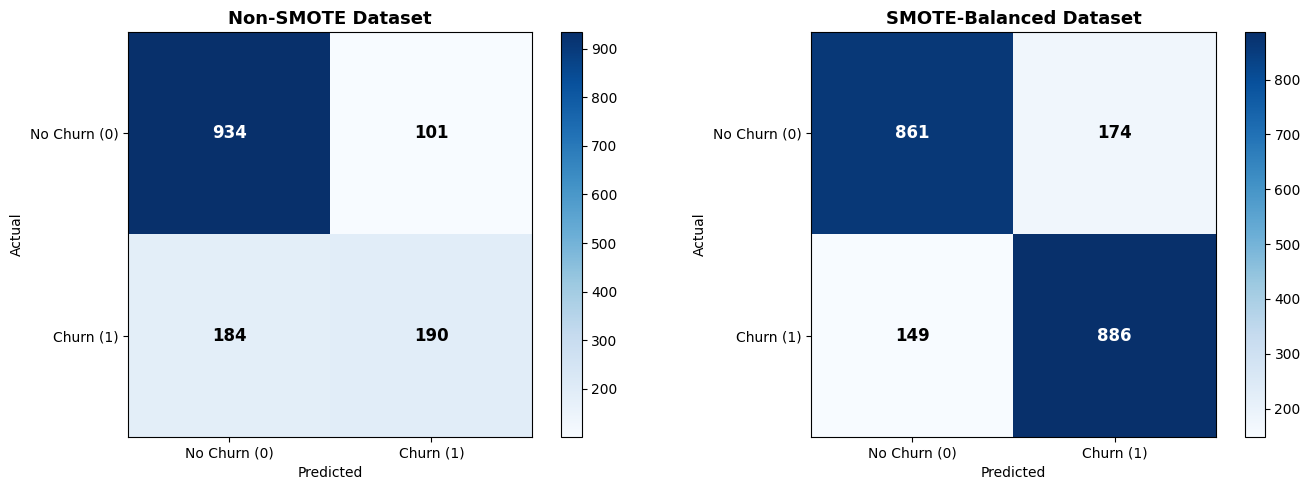

In [6]:
# Calculate confusion matrices
cm_original = confusion_matrix(y_test_original, y_pred_original)
cm_smote = confusion_matrix(y_test_smote, y_pred_smote)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Non-SMOTE Confusion Matrix
im1 = axes[0].imshow(cm_original, cmap='Blues')
axes[0].set_title('Non-SMOTE Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0].set_yticklabels(['No Churn (0)', 'Churn (1)'])

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_original[i, j]), ha='center', va='center', 
                    color='white' if cm_original[i, j] > cm_original.max()/2 else 'black', 
                    fontsize=12, fontweight='bold')

plt.colorbar(im1, ax=axes[0])

# SMOTE Confusion Matrix
im2 = axes[1].imshow(cm_smote, cmap='Blues')
axes[1].set_title('SMOTE-Balanced Dataset', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[1].set_yticklabels(['No Churn (0)', 'Churn (1)'])

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_smote[i, j]), ha='center', va='center', 
                    color='white' if cm_smote[i, j] > cm_smote.max()/2 else 'black', 
                    fontsize=12, fontweight='bold')

plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

## Step 6: Performance Metrics Visualization

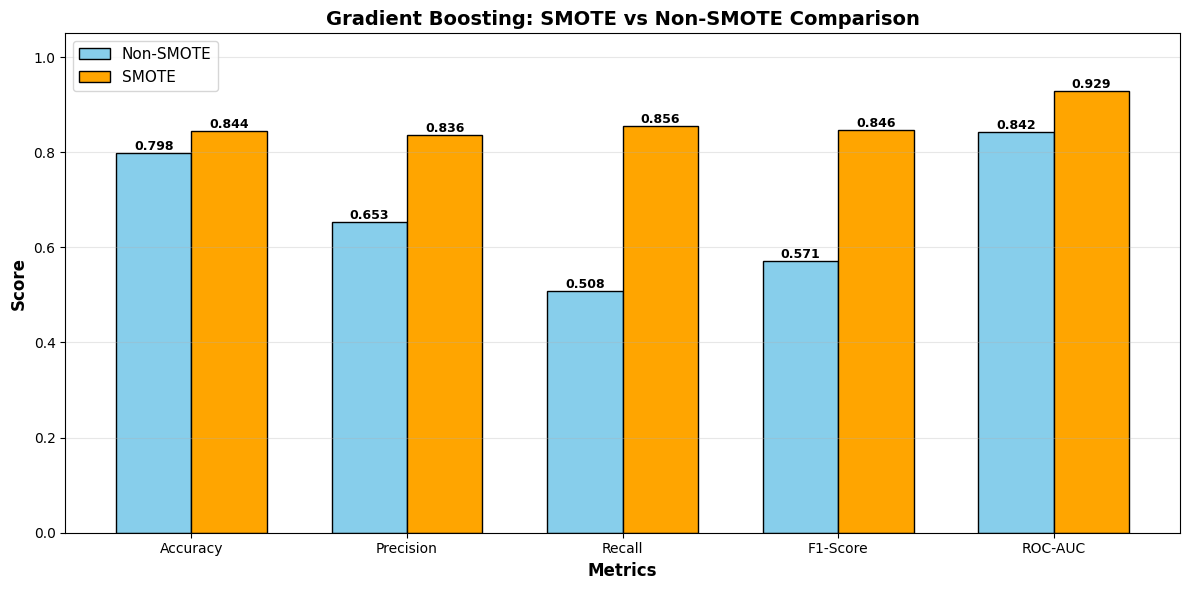

In [7]:
# Create a comparison bar chart for all metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
non_smote_scores = [accuracy_orig, precision_orig, recall_orig, f1_orig, roc_auc_orig]
smote_scores = [accuracy_smote, precision_smote, recall_smote, f1_smote, roc_auc_smote]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, non_smote_scores, width, label='Non-SMOTE', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, smote_scores, width, label='SMOTE', color='orange', edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_title('Gradient Boosting: SMOTE vs Non-SMOTE Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 7: Key Insights & Summary

In [10]:
# Summary - Final Results Comparison
import pandas as pd

results = {
    'Model': ['Non-SMOTE', 'SMOTE '],
    'Accuracy': [accuracy_orig, accuracy_smote],
    'Precision': [precision_orig, precision_smote],
    'Recall': [recall_orig, recall_smote],
    'F1-Score': [f1_orig, f1_smote],
    'ROC-AUC': [roc_auc_orig, roc_auc_smote]
}

results_df = pd.DataFrame(results)
print("\n" + "=" * 100)
print("FINAL RESULTS COMPARISON")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Show which model is better
print(f"\nBetter Model: SMOTE with F1-Score of {f1_smote:.4f} vs Non-SMOTE's {f1_orig:.4f}")


FINAL RESULTS COMPARISON
    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Non-SMOTE  0.797729   0.652921 0.508021  0.571429 0.842028
   SMOTE   0.843961   0.835849 0.856039  0.845823 0.928958

Better Model: SMOTE with F1-Score of 0.8458 vs Non-SMOTE's 0.5714
